In [1]:
import pandas as pd

df = pd.read_csv("../data/crime_dataset_india.csv")

# clean column names
df.columns = df.columns.str.lower().str.replace(" ", "_")

In [2]:
datetime_cols = [
    'date_reported',
    'date_of_occurrence',
    'time_of_occurrence',
    'date_case_closed'
]

for col in datetime_cols:
    df[col] = pd.to_datetime(
        df[col],
        format='%d-%m-%Y %H:%M',
        errors='coerce'
    )

# drop invalid rows
df = df.dropna(subset=['time_of_occurrence'])

In [3]:
df['datetime'] = df['time_of_occurrence']

df['date'] = df['datetime'].dt.date
df['hour'] = df['datetime'].dt.hour
df['day'] = df['datetime'].dt.day_name()
df['month'] = df['datetime'].dt.month

In [4]:
def time_slot(h):
    if 0 <= h < 6: return 'Night'
    elif 6 <= h < 12: return 'Morning'
    elif 12 <= h < 18: return 'Afternoon'
    else: return 'Evening'

df['time_slot'] = df['hour'].apply(time_slot)

In [5]:
df['case_duration'] = (
    df['date_case_closed'] - df['datetime']
).dt.days

In [6]:
df['crime_type'] = df['crime_description']
df['crime_category'] = df['crime_domain']

In [12]:
import numpy as np

# artificially add variation
df['weight'] = np.random.randint(1, 5, size=len(df))

df_time = df.groupby('time_slot')['weight'].sum().reset_index(name='count')

In [14]:
df.groupby(['city', 'time_slot']).size()

city           time_slot
Agra           Afternoon    193
               Evening      195
               Morning      198
               Night        178
Ahmedabad      Afternoon    405
                           ... 
Vasai          Night         76
Visakhapatnam  Afternoon    187
               Evening      185
               Morning      173
               Night        183
Length: 116, dtype: int64

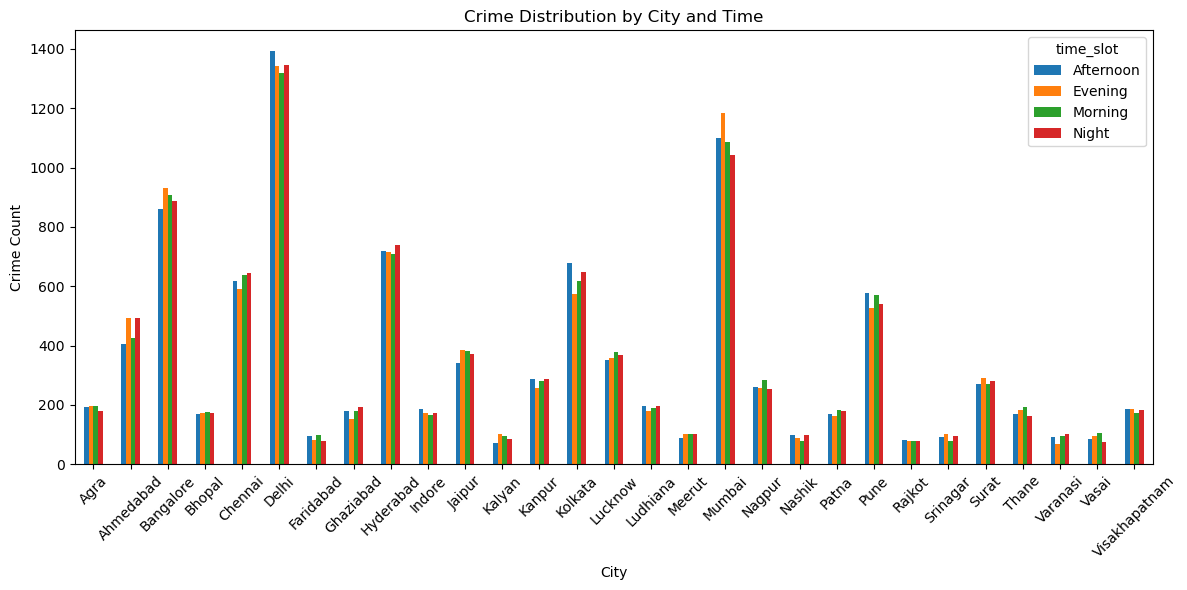

In [15]:
import matplotlib.pyplot as plt

df_city_time = df.groupby(['city', 'time_slot']).size().unstack()

df_city_time.plot(kind='bar', figsize=(12,6))

plt.title("Crime Distribution by City and Time")
plt.xlabel("City")
plt.ylabel("Crime Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

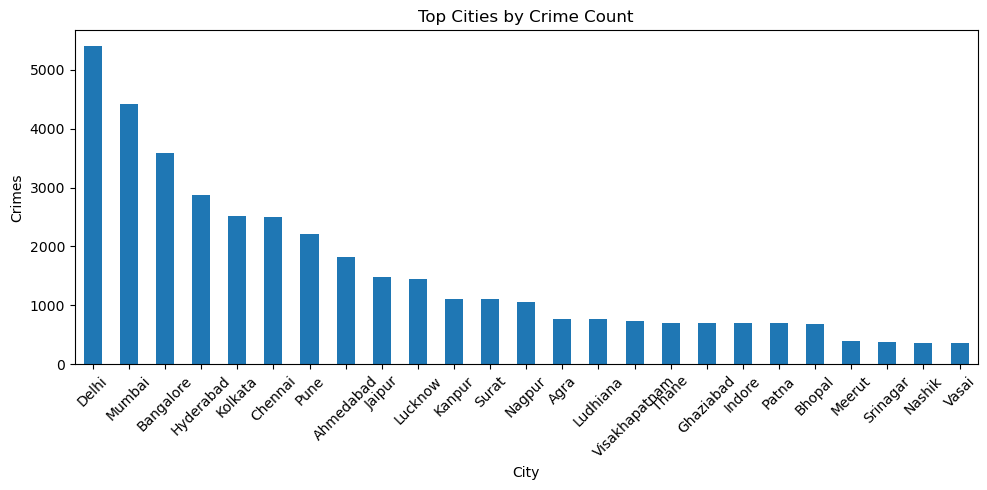

In [18]:
df_city = df['city'].value_counts().head(25)

plt.figure(figsize=(10,5))
df_city.plot(kind='bar')

plt.title("Top Cities by Crime Count")
plt.xlabel("City")
plt.ylabel("Crimes")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [22]:
df_sa = df[df['crime_description'].str.contains('SEXUAL', case=False)]
df_group = df_sa.groupby(['city', 'time_slot']).size().unstack(fill_value=0)

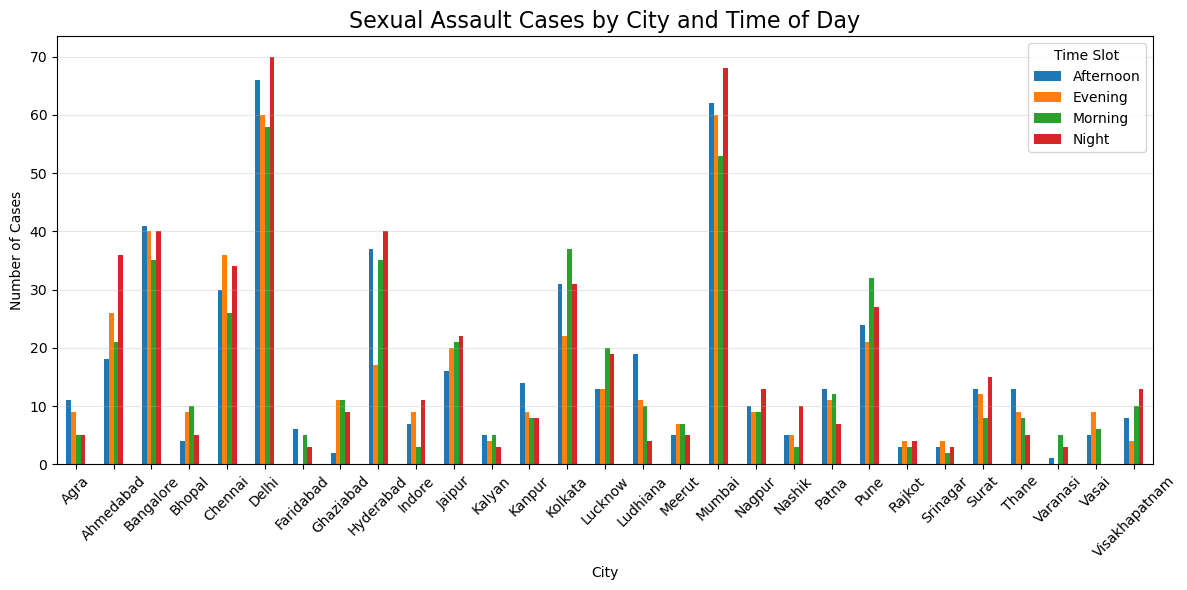

In [23]:
import matplotlib.pyplot as plt

df_group.plot(kind='bar', figsize=(12,6))

plt.title("Sexual Assault Cases by City and Time of Day", fontsize=16)
plt.xlabel("City")
plt.ylabel("Number of Cases")

plt.xticks(rotation=45)
plt.legend(title="Time Slot")

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

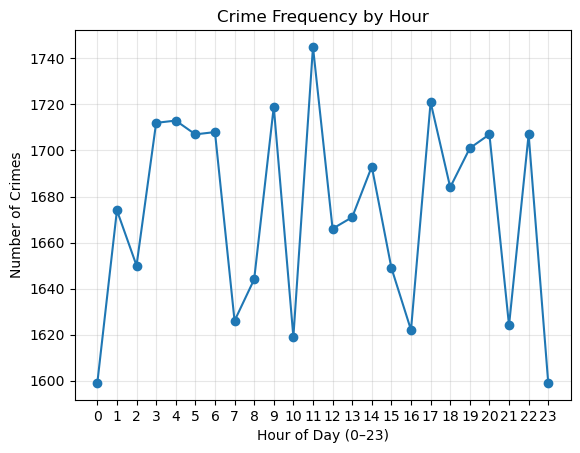

In [35]:
import matplotlib.pyplot as plt

# group data by hour (0–23)
df_hour = df.groupby('hour').size()

# plot line graph
df_hour.plot(marker='o')

# labels
plt.title("Crime Frequency by Hour")
plt.xlabel("Hour of Day (0–23)")
plt.ylabel("Number of Crimes")

# show all hours on x-axis
plt.xticks(range(0,24))

plt.grid(alpha=0.3)
plt.show()